In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
class Model(nn.Module):
  def __init__(self, in_features=4, h1=8, h2=8, out_features=3):
    super().__init__()
    self.fc1 = nn.Linear(in_features, h1)
    self.fc2 = nn.Linear(h1, h2)
    self.out = nn.Linear(h2, out_features)
  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.out(x)

    return x

In [50]:
torch.manual_seed(42)
model = Model()



In [6]:
import matplotlib.pyplot as plt
import pandas as pd
%matplotlib inline

In [8]:
url = 'https://gist.githubusercontent.com/curran/a08a1080b88344b0c8a7/raw/0e7a9b0a5d22642a06d3d5b9bcbad9890c8ee534/iris.csv'
my_df = pd.read_csv(url)

In [9]:
my_df

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,virginica
146,6.3,2.5,5.0,1.9,virginica
147,6.5,3.0,5.2,2.0,virginica
148,6.2,3.4,5.4,2.3,virginica


In [18]:
my_df['species'] = my_df['species'].replace("setosa", 0.8)
my_df['species'] = my_df['species'].replace("versicolor", 0.8)
my_df['species'] = my_df['species'].replace("virginica", 0.8)

/tmp/ipykernel_17190/4188936468.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  my_df['species'] = my_df['species'].replace("virginica", 0.8)


In [19]:
my_df.head()


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,0.8
1,4.9,3.0,1.4,0.2,0.8
2,4.7,3.2,1.3,0.2,0.8
3,4.6,3.1,1.5,0.2,0.8
4,5.0,3.6,1.4,0.2,0.8


In [21]:
X = my_df.drop('species', axis=1)
y = my_df['species']

In [24]:
X = X.values

In [23]:
y = y.values

In [25]:
from sklearn.model_selection import train_test_split

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=41)

In [45]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)

In [46]:
y_train = torch.LongTensor(y_train)
y_test = torch.LongTensor(y_test)

In [47]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [51]:
epoch = 100
losses = []
for i in range(epoch):
  y_pred = model.forward(X_train)
  loss = criterion(y_pred, y_train)
  losses.append(loss.detach().numpy())
  if i % 10 == 0:
    print(f'Epoch: {i} and loss: {loss}')

  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

Epoch: 0 and loss: 1.4769959449768066
Epoch: 10 and loss: 1.4769959449768066
Epoch: 20 and loss: 1.4769959449768066
Epoch: 30 and loss: 1.4769959449768066
Epoch: 40 and loss: 1.4769959449768066
Epoch: 50 and loss: 1.4769959449768066
Epoch: 60 and loss: 1.4769959449768066
Epoch: 70 and loss: 1.4769959449768066
Epoch: 80 and loss: 1.4769959449768066
Epoch: 90 and loss: 1.4769959449768066


Text(0.5, 0, 'epoch')

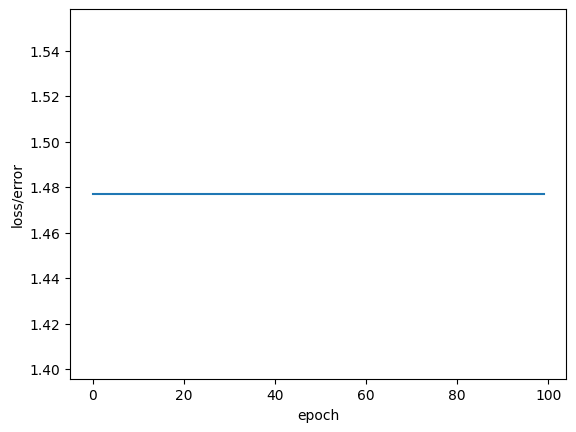

In [52]:
plt.plot(range(epoch), losses)
plt.ylabel("loss/error")
plt.xlabel("epoch")